# 🚀 Credit Scoring Model

### CodeAlpha Machine Learning Internship

**Objective:** Predict whether a loan is likely to be fully paid or not using Machine Learning.

**Models Used:**
- Logistic Regression
- Random Forest

**Evaluation Metrics:**
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/loan_data.csv"

df = pd.read_csv(url)

df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## 3. Data Exploration


In [3]:
print(df.shape)
print(df.columns)

(9578, 14)
Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='object')


In [4]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


## 4. Data Analysis

In [5]:
df.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [6]:
df['not.fully.paid'].value_counts()
df['not.fully.paid'].value_counts(normalize=True) * 100

,proportion
not.fully.paid,
0,83.994571
1,16.005429


## 5. Data Preprocessing

In [7]:
X = df.drop('not.fully.paid', axis=1)
y = df['not.fully.paid']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9578, 13)
Target shape: (9578,)


In [8]:
X.dtypes

,0
credit.policy,int64
purpose,object
int.rate,float64
installment,float64
log.annual.inc,float64
dti,float64
fico,int64
days.with.cr.line,float64
revol.bal,int64
revol.util,float64


In [9]:
X = pd.get_dummies(X, columns=['purpose'], drop_first=True)

print("New features shape:", X.shape)
X.head()

New features shape: (9578, 18)


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,False,True,False,False,False,False
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,True,False,False,False,False,False
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,False,True,False,False,False,False
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,False,True,False,False,False,False
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,True,False,False,False,False,False


## 6. Train-Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7662, 18)
Testing data: (1916, 18)


## 7. Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
import joblib

joblib.dump(model, "trained_model.pkl")

['trained_model.pkl']

In [13]:
from google.colab import files

files.download("trained_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.8397703549060542
Precision: 0.5
Recall   : 0.029315960912052116
F1-Score : 0.055384615384615386


Confusion Matrix:
[[1600    9]
 [ 298    9]]


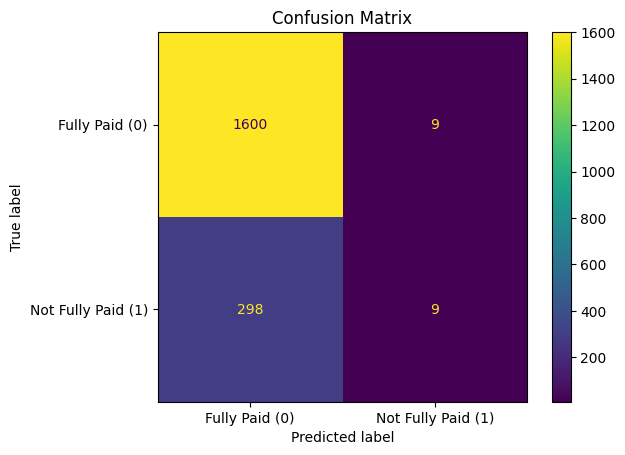

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fully Paid (0)", "Not Fully Paid (1)"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability predictions
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6647259005229136


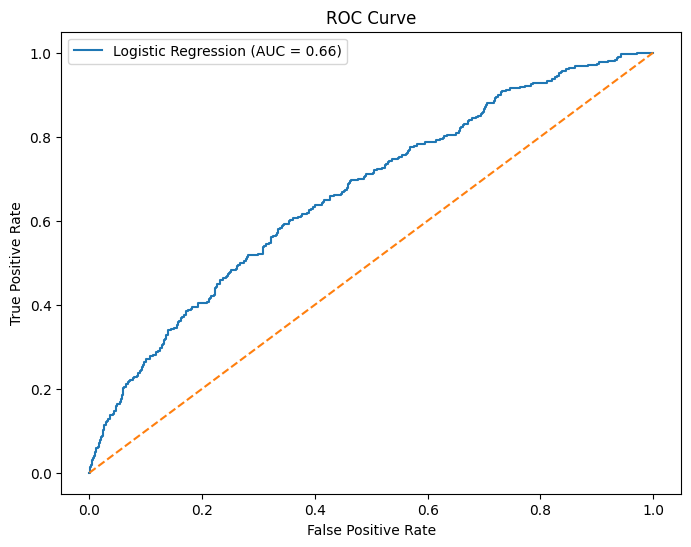

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 8. Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [20]:
rf_pred = rf_model.predict(X_test)

print(rf_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


In [21]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.8355949895615866
Precision: 0.21428571428571427
Recall   : 0.009771986970684038
F1-Score : 0.018691588785046728


In [22]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get probability predictions
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC Score:", rf_roc_auc)

Random Forest ROC-AUC Score: 0.6547828481080568


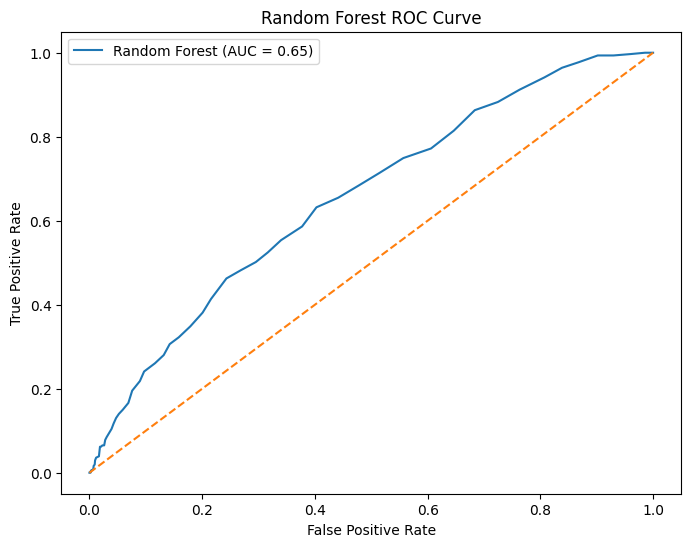

In [23]:
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_roc_auc:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()

plt.show()

## 9. Model Comparison

In [24]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1-Score": [f1, rf_f1],
    "ROC-AUC": [roc_auc, rf_roc_auc]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.839770,0.500000,0.029316,0.055385,0.664726
1,Random Forest,0.835595,0.214286,0.009772,0.018692,0.654783


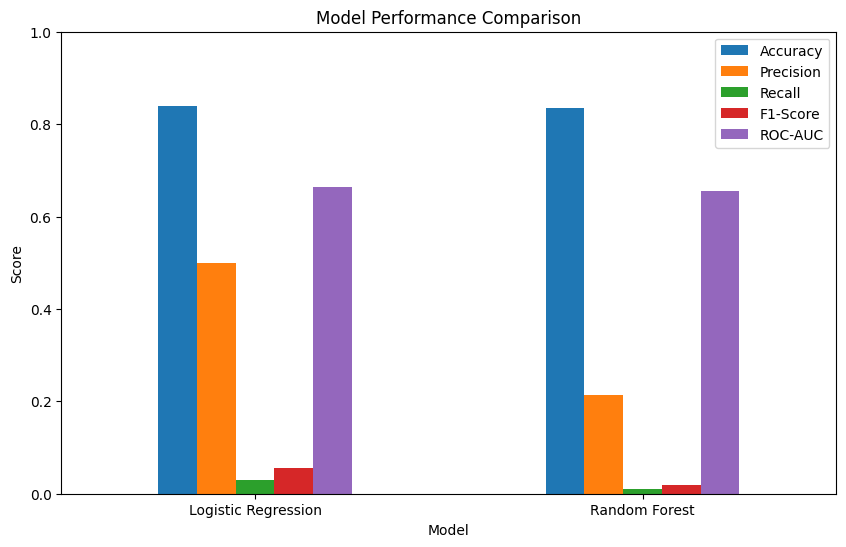

In [25]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

## 10. Feature Importance

In [26]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                       Feature  Importance
2                  installment    0.115671
3               log.annual.inc    0.113071
6            days.with.cr.line    0.112127
8                   revol.util    0.112018
7                    revol.bal    0.111317
4                          dti    0.108347
1                     int.rate    0.104574
5                         fico    0.078851
9               inq.last.6mths    0.054478
0                credit.policy    0.016604
13  purpose_debt_consolidation    0.014291
10                 delinq.2yrs    0.014115
17      purpose_small_business    0.009591
11                     pub.rec    0.008934
15    purpose_home_improvement    0.007775
12         purpose_credit_card    0.007731
14         purpose_educational    0.006354
16      purpose_major_purchase    0.004150


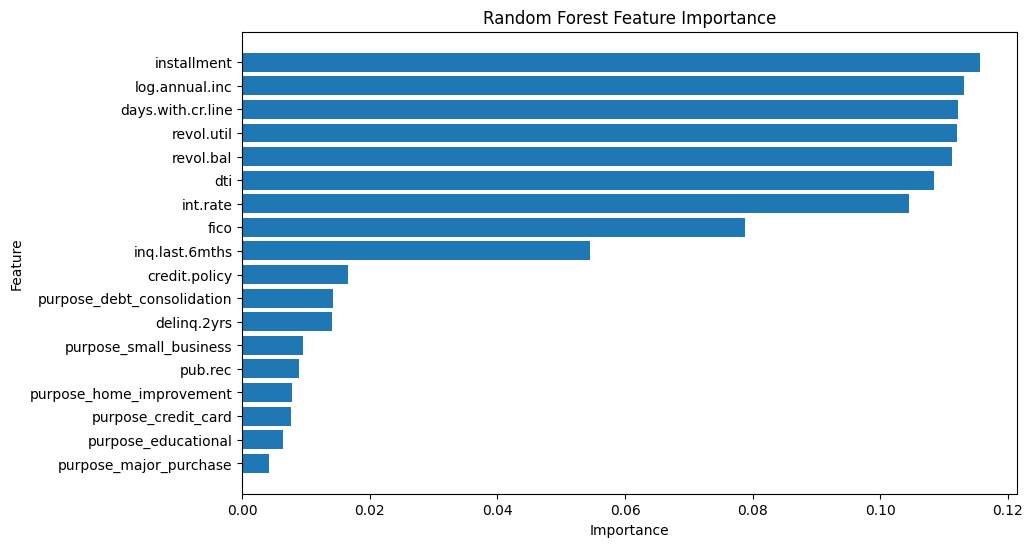

In [27]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## 11. Final Model Selection

In [28]:
best_model = comparison.loc[
    comparison["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model)

Best Model: Logistic Regression


In [29]:
import joblib

if best_model == "Logistic Regression":
    final_model = model
else:
    final_model = rf_model

joblib.dump(final_model, "credit_scoring_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


## 12. Loan Prediction

In [30]:
def predict_loan(income, fico, dti, int_rate, installment):

    new_data = pd.DataFrame({
        "log.annual.inc": [np.log(income)],
        "fico": [fico],
        "dti": [dti],
        "int.rate": [int_rate],
        "installment": [installment]
    })

    # Add all missing columns used during training
    for column in X.columns:
        if column not in new_data.columns:
            new_data[column] = 0

    # Keep columns in the same order as training data
    new_data = new_data[X.columns]

    prediction = final_model.predict(new_data)[0]

    if prediction == 0:
        return "Loan is likely to be FULLY PAID"
    else:
        return "Loan is likely to be NOT FULLY PAID"

In [31]:
result = predict_loan(
    income=50000,
    fico=700,
    dti=15,
    int_rate=0.12,
    installment=300
)

print(result)

Loan is likely to be FULLY PAID


## 12. Loan Prediction

In [32]:
from sklearn.metrics import classification_report

print("Final Model:", best_model)
print("\nClassification Report:")
print(classification_report(
    y_test,
    final_model.predict(X_test),
    target_names=["Fully Paid", "Not Fully Paid"]
))

Final Model: Logistic Regression

Classification Report:
                precision    recall  f1-score   support

    Fully Paid       0.84      0.99      0.91      1609
Not Fully Paid       0.50      0.03      0.06       307

      accuracy                           0.84      1916
     macro avg       0.67      0.51      0.48      1916
  weighted avg       0.79      0.84      0.78      1916



## 14. Final Results

In [33]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

final_results

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.839770,0.835595
1,Precision,0.500000,0.214286
2,Recall,0.029316,0.009772
3,F1-Score,0.055385,0.018692
4,ROC-AUC,0.664726,0.654783


In [34]:
final_results.round(4)

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8398,0.8356
1,Precision,0.5000,0.2143
2,Recall,0.0293,0.0098
3,F1-Score,0.0554,0.0187
4,ROC-AUC,0.6647,0.6548


In [35]:
final_results.round(4).to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


---

# 🎯 Conclusion

This project developed a machine learning-based Credit Scoring Model to predict whether a loan is likely to be fully paid or not.

Two classification algorithms, Logistic Regression and Random Forest, were trained and evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The model with the better overall performance was selected as the final model.

This project demonstrates how Machine Learning can be applied to credit risk and loan repayment prediction.

---